In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For data augmentation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Load and Preprocess MNIST Data

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000, 10)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000, 10)


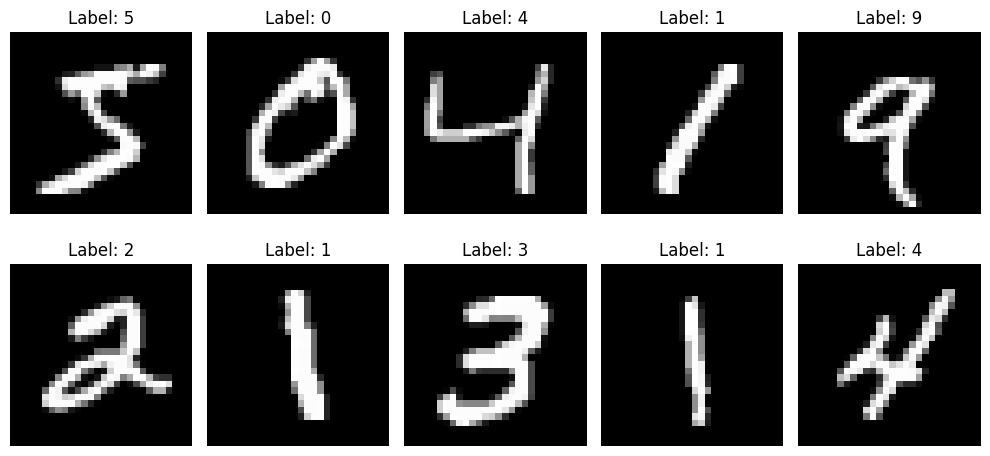

In [2]:
# Step 1: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Step 2: Data Preprocessing
# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to 28x28x1 for CNN input (1 channel for grayscale images)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Convert labels to one-hot encoding for multi-class classification
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Check the shapes of our data
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Visualize some example images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Setup Data Augmentation

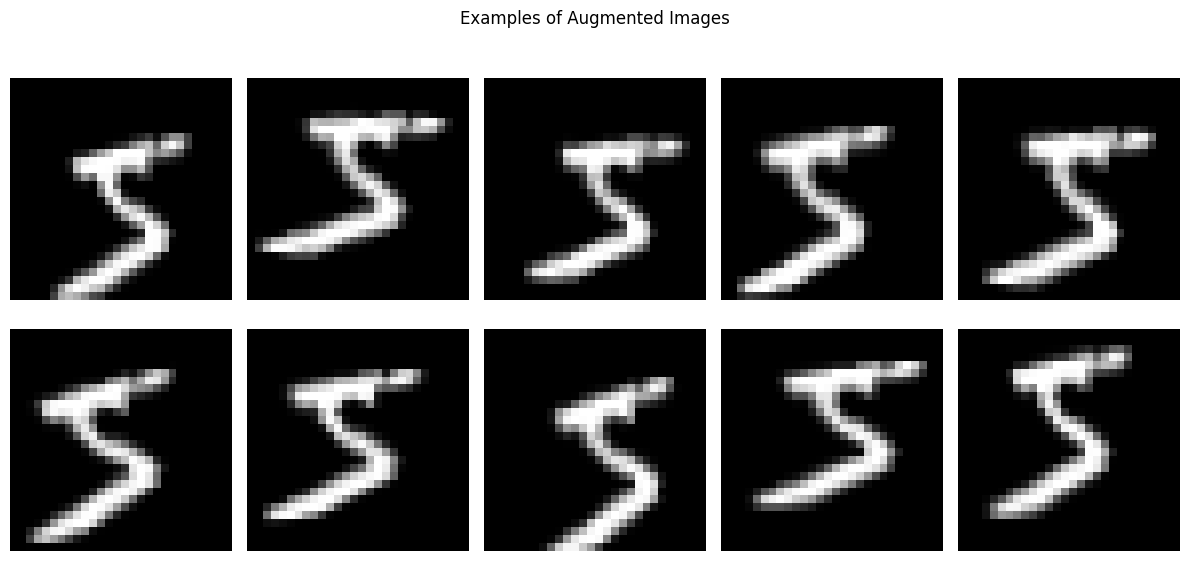

In [3]:
# Step 3: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate images by up to 10 degrees
    zoom_range=0.1,         # Randomly zoom images by up to 10%
    width_shift_range=0.1,  # Randomly shift images horizontally by up to 10%
    height_shift_range=0.1  # Randomly shift images vertically by up to 10%
)
datagen.fit(x_train)  # Fit the data generator to the training data

# Visualize some augmented images
plt.figure(figsize=(12, 6))
for i, (images, _) in enumerate(datagen.flow(x_train[0:1], y_train[0:1], batch_size=1)):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[0].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i >= 9:
        break
plt.suptitle("Examples of Augmented Images")
plt.tight_layout()
plt.show()

Build and Compile CNN Model

In [4]:
# Step 4: Model Selection & Training
# Define the CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

Train the CNN Model

In [5]:
# Define callbacks for early stopping and learning rate reduction
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
]

# Train the model with data augmentation
history = model.fit(datagen.flow(x_train, y_train, batch_size=128),
                    epochs=20,
                    validation_data=(x_test, y_test),
                    callbacks=callbacks)

Epoch 1/20
469/469 [==============================] - 57s 121ms/step - loss: 0.5572 - accuracy: 0.8205 - val_loss: 0.0617 - val_accuracy: 0.9820 - lr: 0.0010
Epoch 2/20
469/469 [==============================] - 134s 285ms/step - loss: 0.2107 - accuracy: 0.9372 - val_loss: 0.0448 - val_accuracy: 0.9849 - lr: 0.0010
Epoch 3/20
469/469 [==============================] - 120s 256ms/step - loss: 0.1630 - accuracy: 0.9506 - val_loss: 0.0306 - val_accuracy: 0.9888 - lr: 0.0010
Epoch 4/20
469/469 [==============================] - 46s 98ms/step - loss: 0.1352 - accuracy: 0.9597 - val_loss: 0.0275 - val_accuracy: 0.9901 - lr: 0.0010
Epoch 5/20
469/469 [==============================] - 22s 47ms/step - loss: 0.1204 - accuracy: 0.9631 - val_loss: 0.0309 - val_accuracy: 0.9887 - lr: 0.0010
Epoch 6/20
469/469 [==============================] - 36s 78ms/step - loss: 0.1032 - accuracy: 0.9695 - val_loss: 0.0243 - val_accuracy: 0.9904 - lr: 0.0010
Epoch 7/20
469/469 [==============================] -

Evaluate Model Performance

313/313 - 2s - loss: 0.0153 - accuracy: 0.9949 - 2s/epoch - 7ms/step

Test Accuracy: 0.9949


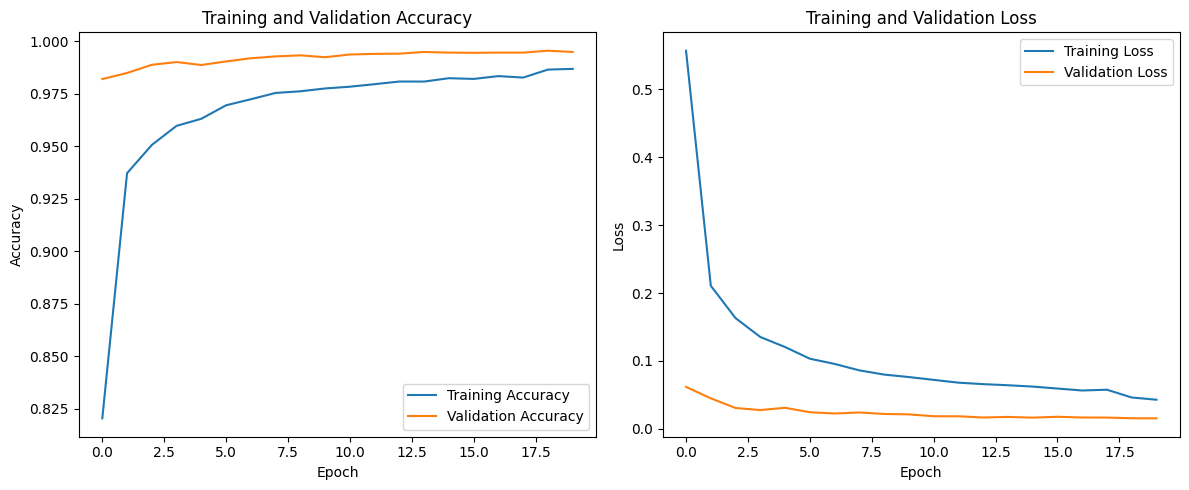

In [6]:
# Step 5: Evaluation & Optimization
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot training/validation accuracy and loss
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Generate Confusion Matrix and Classification Report

313/313 [==============================] - 3s 8ms/step


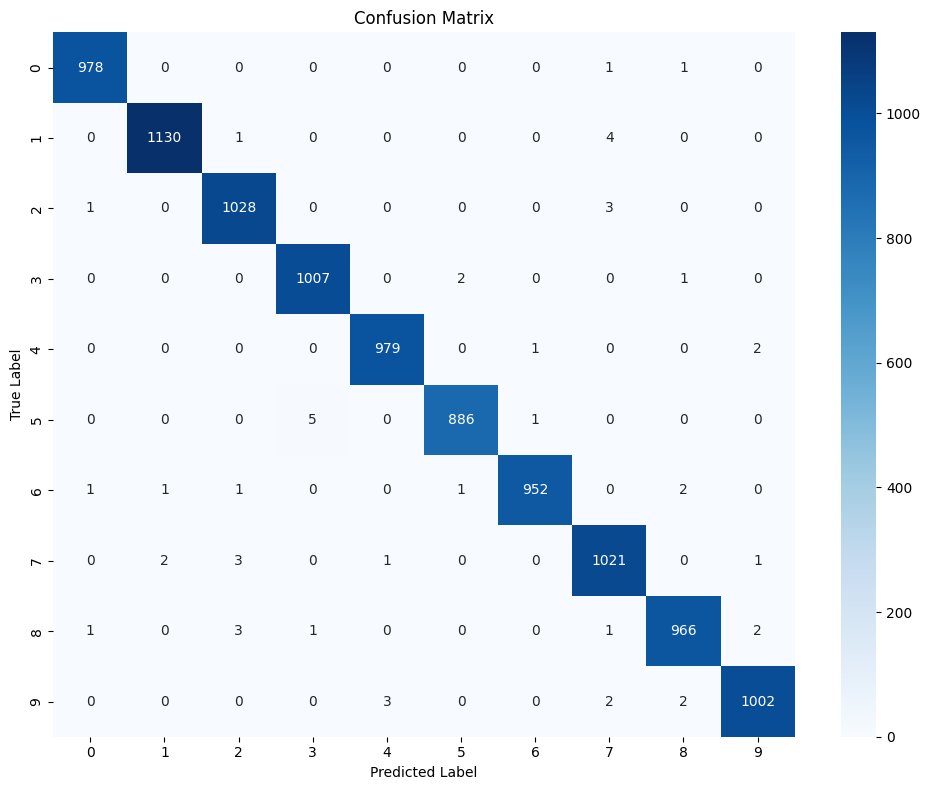


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
# Generate predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))

Visualize Model Predictions

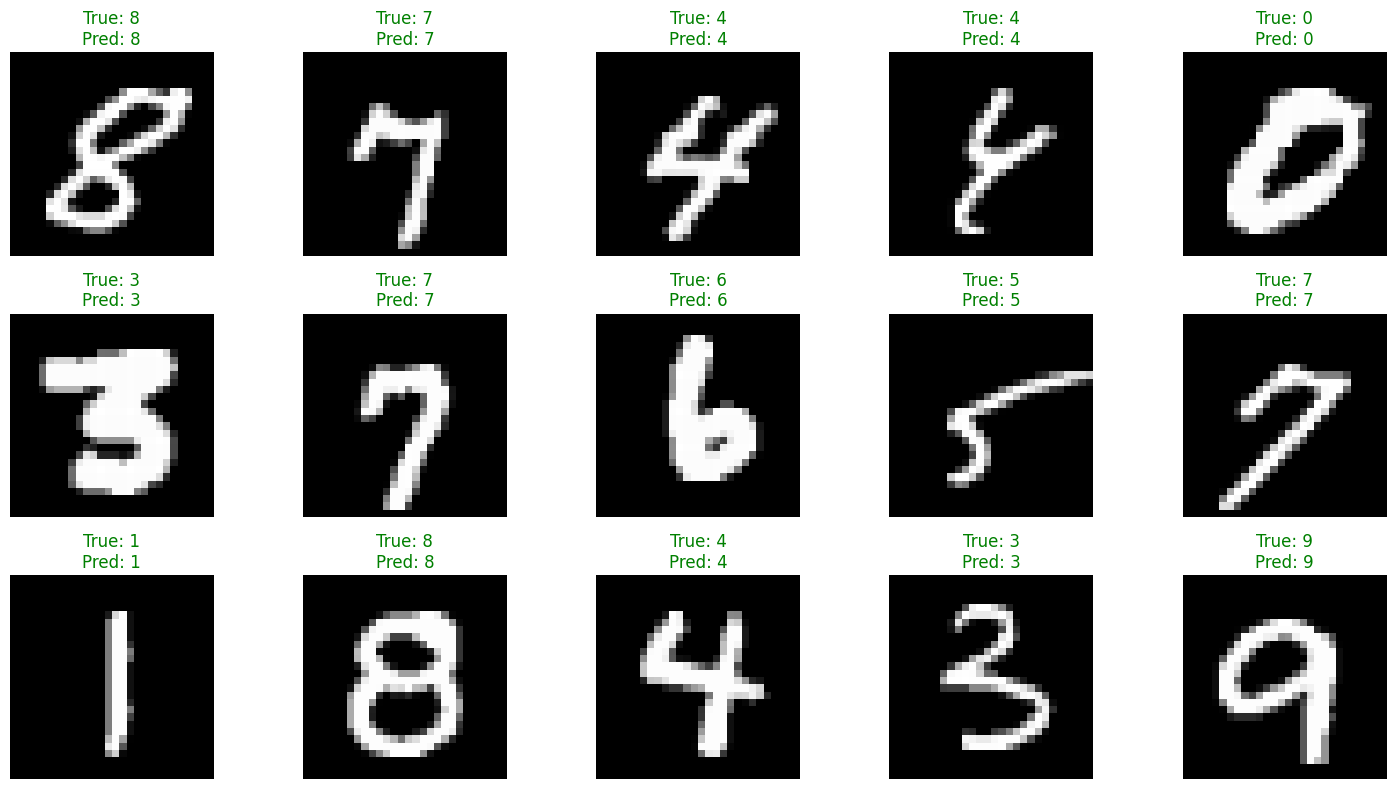

In [8]:
# Visualize some example predictions
num_examples = 15
indices = np.random.choice(range(len(x_test)), num_examples)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 5, i+1)
    img = x_test[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    
    pred_label = y_pred_classes[idx]
    true_label = y_true_classes[idx]
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

Simple Hyperparameter Tuning

In [9]:
# Step 6: Hyperparameter Tuning (Optional)
# This is a simplified version of hyperparameter tuning
best_accuracy = 0
best_params = {}

# Test different numbers of filters in the first Conv2D layer
for filters in [32, 64]:
    print(f"\nTesting model with {filters} filters in first layer")
    
    # Build model with current hyperparameters
    model_tune = models.Sequential([
        layers.Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    
    model_tune.compile(optimizer='adam', 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])
    
    # Train for fewer epochs for faster tuning
    history = model_tune.fit(datagen.flow(x_train, y_train, batch_size=128),
                        epochs=5,  # Reduced epochs for faster tuning
                        validation_data=(x_test, y_test),
                        verbose=1)
    
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_params = {'filters': filters}

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")


Testing model with 32 filters in first layer
Epoch 1/5
469/469 [==============================] - 30s 63ms/step - loss: 0.5373 - accuracy: 0.8275 - val_loss: 0.0685 - val_accuracy: 0.9782
Epoch 2/5
469/469 [==============================] - 72s 153ms/step - loss: 0.2145 - accuracy: 0.9349 - val_loss: 0.0399 - val_accuracy: 0.9859
Epoch 3/5
469/469 [==============================] - 58s 123ms/step - loss: 0.1676 - accuracy: 0.9487 - val_loss: 0.0359 - val_accuracy: 0.9878
Epoch 4/5
469/469 [==============================] - 53s 112ms/step - loss: 0.1390 - accuracy: 0.9580 - val_loss: 0.0266 - val_accuracy: 0.9912
Epoch 5/5
469/469 [==============================] - 25s 54ms/step - loss: 0.1221 - accuracy: 0.9633 - val_loss: 0.0236 - val_accuracy: 0.9921

Testing model with 64 filters in first layer
Epoch 1/5
469/469 [==============================] - 135s 288ms/step - loss: 0.5202 - accuracy: 0.8353 - val_loss: 0.0695 - val_accuracy: 0.9779
Epoch 2/5
469/469 [==========================

Save and Load the Trained Model

In [10]:
# Save the model
model.save('mnist_cnn_model.h5')
print("Model saved as 'mnist_cnn_model.h5'")

# To load the model in a future session, you would use:
# loaded_model = tf.keras.models.load_model('mnist_cnn_model.h5')

Model saved as 'mnist_cnn_model.h5'
